# Lab 12: Bosques aleatorios

El árbol de decisión individual tiende a sobreajustarse: aprende demasiado bien el train pero generaliza mal.
Random Forest resuelve esto entrenando muchos árboles sobre subconjuntos distintos del dataset (bootstrapping)
y tomando decisión por votación mayoritaria.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

np.random.seed(42)

## 1. Bootstrapping: la base del bosque

El bootstrapping consiste en muestrear con reposición un subconjunto del dataset para cada árbol.
Esto hace que cada árbol vea datos ligeramente distintos y cometa errores distintos,
lo que reduce la varianza al promediar las predicciones.

In [2]:
# Ejemplo de bootstrapping con 4 muestras y 5 árboles
n_muestras = 4
n_arboles = 5
indices_bootstrap = np.random.randint(0, n_muestras, (n_arboles, n_muestras))

print('Índices de bootstrapping (cada fila es el dataset de un árbol):')
print(indices_bootstrap)
print()
print('Cada árbol usa un subconjunto distinto (con repetición) de los datos originales.')

Índices de bootstrapping (cada fila es el dataset de un árbol):
[[2 3 0 2]
 [2 3 0 0]
 [2 1 2 2]
 [2 2 3 0]
 [3 3 3 2]]

Cada árbol usa un subconjunto distinto (con repetición) de los datos originales.


## 2. Dataset: dígitos manuscritos

Cargamos `load_digits`, que contiene imágenes de 8x8 píxeles de dígitos del 0 al 9.

In [3]:
digits = load_digits()
X, y = digits.data, digits.target

print(f'Forma del dataset: {X.shape}')
print(f'Clases: {digits.target_names}')
print(f'Distribución por clase:')
unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))

Forma del dataset: (1797, 64)
Clases: [0 1 2 3 4 5 6 7 8 9]
Distribución por clase:
{np.int64(0): np.int64(178), np.int64(1): np.int64(182), np.int64(2): np.int64(177), np.int64(3): np.int64(183), np.int64(4): np.int64(181), np.int64(5): np.int64(182), np.int64(6): np.int64(181), np.int64(7): np.int64(179), np.int64(8): np.int64(174), np.int64(9): np.int64(180)}


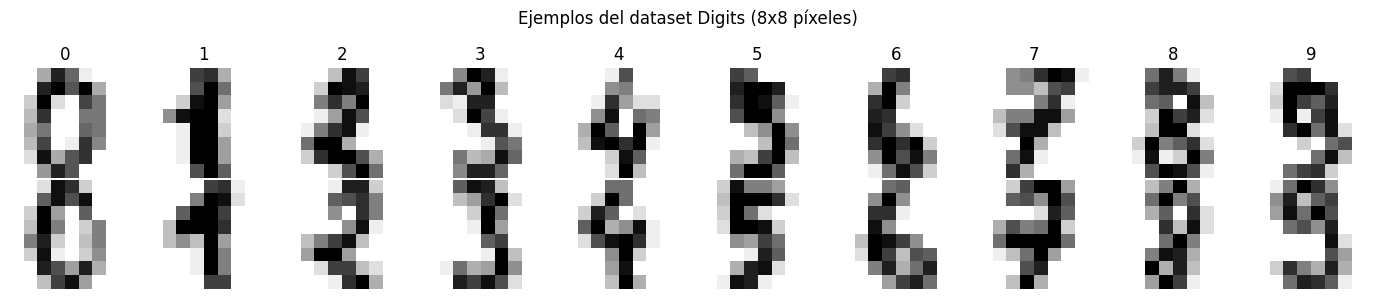

In [4]:
# Visualizamos algunos dígitos del dataset
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for digito in range(10):
    idx = np.where(y == digito)[0][0]
    axes[0, digito].imshow(digits.images[idx], cmap='gray_r')
    axes[0, digito].set_title(str(digito))
    axes[0, digito].axis('off')

    idx2 = np.where(y == digito)[0][5]
    axes[1, digito].imshow(digits.images[idx2], cmap='gray_r')
    axes[1, digito].axis('off')

plt.suptitle('Ejemplos del dataset Digits (8x8 píxeles)')
plt.tight_layout()
plt.show()

## 3. Árbol individual vs Random Forest

Comparamos directamente: un árbol solo vs un bosque de 100 árboles, mismo dataset.

In [5]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Árbol individual (sin límite de profundidad: tiende a sobreajustarse)
arbol = DecisionTreeClassifier(random_state=42)
arbol.fit(X_tr, y_tr)
acc_arbol_tr = accuracy_score(y_tr, arbol.predict(X_tr))
acc_arbol_te = accuracy_score(y_te, arbol.predict(X_te))

# Random Forest
bosque = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
bosque.fit(X_tr, y_tr)
acc_bosque_tr = accuracy_score(y_tr, bosque.predict(X_tr))
acc_bosque_te = accuracy_score(y_te, bosque.predict(X_te))

comparacion = pd.DataFrame({
    'modelo': ['Árbol individual', 'Random Forest (100)'],
    'acc_train': [acc_arbol_tr, acc_bosque_tr],
    'acc_test': [acc_arbol_te, acc_bosque_te],
    'gap': [acc_arbol_tr - acc_arbol_te, acc_bosque_tr - acc_bosque_te]
})

display(comparacion.round(4))
print('El árbol individual tiene acc_train=1.0 (memoriza todo) pero cae en test: overfitting.')
print('El bosque tiene train más bajo pero test mucho mejor: mejor generalización.')

,modelo,acc_train,acc_test,gap
0,Árbol individual,1.0,0.8250,0.1750
1,Random Forest (100),1.0,0.9611,0.0389


El árbol individual tiene acc_train=1.0 (memoriza todo) pero cae en test: overfitting.
El bosque tiene train más bajo pero test mucho mejor: mejor generalización.


## 4. Reporte de clasificación y matriz de confusión

In [6]:
print(classification_report(y_te, bosque.predict(X_te), target_names=[str(i) for i in range(10)]))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.90      0.97      0.93        36
           2       1.00      0.97      0.99        35
           3       0.97      0.97      0.97        37
           4       0.97      0.97      0.97        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       0.92      1.00      0.96        36
           8       0.94      0.86      0.90        35
           9       0.97      0.92      0.94        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



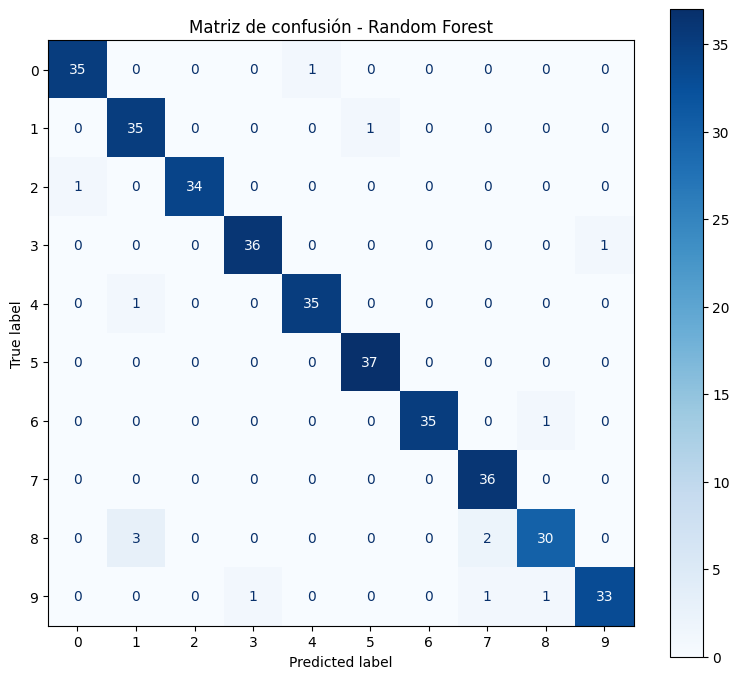

La mayoría de los errores son entre dígitos visualmente similares (1-7, 3-5, 8-9).


In [7]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_estimator(
    bosque, X_te, y_te,
    display_labels=digits.target_names,
    cmap='Blues', ax=ax
)
plt.title('Matriz de confusión - Random Forest')
plt.tight_layout()
plt.show()

print('La mayoría de los errores son entre dígitos visualmente similares (1-7, 3-5, 8-9).')

## 5. Efecto del número de árboles

Más árboles generalmente mejoran el resultado, pero con rendimientos decrecientes.
Hay un punto a partir del cual agregar más árboles no ayuda pero sí cuesta tiempo.

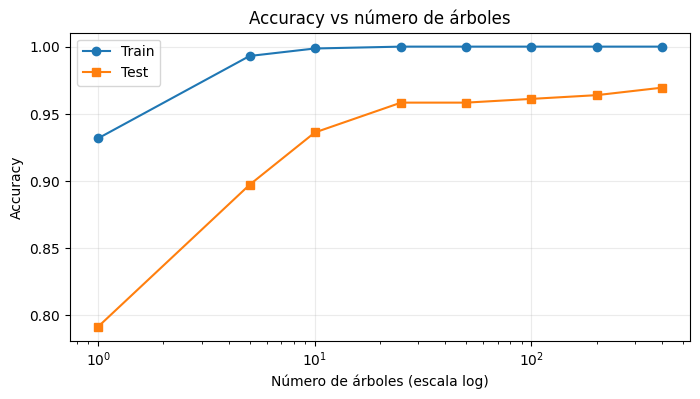

Con 100 árboles ya se estabiliza bastante: acc_test = 0.9611
Doblar a 200 o 400 aporta muy poco.


In [8]:
n_estimadores = [1, 5, 10, 25, 50, 100, 200, 400]
acc_te_list = []
acc_tr_list = []

for n in n_estimadores:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    acc_tr_list.append(accuracy_score(y_tr, rf.predict(X_tr)))
    acc_te_list.append(accuracy_score(y_te, rf.predict(X_te)))

plt.figure(figsize=(8, 4))
plt.semilogx(n_estimadores, acc_tr_list, marker='o', label='Train')
plt.semilogx(n_estimadores, acc_te_list, marker='s', label='Test')
plt.xlabel('Número de árboles (escala log)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs número de árboles')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print(f'Con 100 árboles ya se estabiliza bastante: acc_test = {acc_te_list[5]:.4f}')
print('Doblar a 200 o 400 aporta muy poco.')

## 6. Importancia de características (píxeles)

El bosque nos dice qué píxeles de la imagen de 8x8 son más informativos para clasificar el dígito.

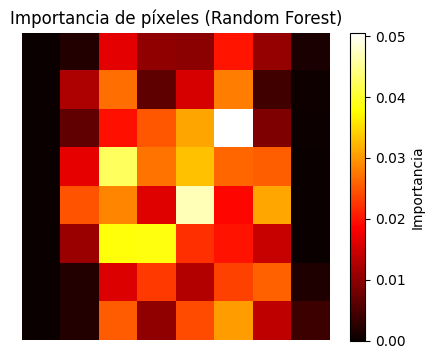

Los píxeles del centro y los bordes son los más importantes.
Los esquinas tienen poca información porque los dígitos casi nunca las usan.


In [9]:
importancias = bosque.feature_importances_.reshape(8, 8)

plt.figure(figsize=(5, 4))
plt.imshow(importancias, cmap='hot', interpolation='nearest')
plt.colorbar(label='Importancia')
plt.title('Importancia de píxeles (Random Forest)')
plt.axis('off')
plt.show()

print('Los píxeles del centro y los bordes son los más importantes.')
print('Los esquinas tienen poca información porque los dígitos casi nunca las usan.')

## Conclusiones

- El árbol individual memoriza el train set (acc=1.0) pero generaliza mal, el bosque lo corrige.
- Con 100 árboles ya se alcanza más del 97% de accuracy en digits, que es muy bueno.
- El mapa de importancias confirma que los píxeles centrales de las imágenes son los más discriminantes.
- El costo computacional crece linealmente con el número de árboles, pero los beneficios se estabilizan rápido.